# Supplement E-commerce Sales Analysis

**Author:** Anchor Miao (Ching-Hung Miao)  |  Python · pandas · Seaborn

An exploratory analysis of **4,384 weekly sales records** for health & wellness supplements (Jan 2020 – Mar 2025), spanning categories like Protein, Vitamins, Omega, and Amino Acids across Amazon, Walmart, and iHerb in the USA, UK, and Canada.

**Goal:** understand what drives revenue — which products, categories, platforms, and regions perform best, and how discounts and returns move the numbers.

**Selected facts:** clean dataset with **no missing values**; average unit price **$34.78**, average weekly revenue per record **≈ $5,227**; revenue analyzed by product, category, platform, and over time.

> Data lives in `./data/`. Run top-to-bottom in Jupyter or Colab.

---


In [ ]:
# @title
print(r"""
            ,--,
     _ ___/ /\|
 ,;'( )__, )  ~
  //  //   '--;
  '  \ \     |
      ^  ^     ^
""")

print("\n🐎 Happy Lunar New Year 2026 — Year of the Horse! 🧧")
print("Wishing you strength, speed, and success in the year ahead!")


            ,--,
     _ ___/ /\|
 ,;'( )__, )  ~
  //  //   '--;
  '  \ \     |
      ^  ^     ^


🐎 Happy Lunar New Year 2026 — Year of the Horse! 🧧
Wishing you strength, speed, and success in the year ahead!


# Background

## This dataset contains weekly sales data for a variety of health and wellness supplements from January 2020 to March 2025. The data includes products in categories like Protein, Vitamins, Omega, and Amino Acids, among others, and covers multiple e-commerce platforms such as Amazon, Walmart, and iHerb. The dataset also tracks sales in several locations including the USA, UK, and Canada.

# Question 1. Source the data using one of the following options:
### (a) Import `Supplement_Sales_Weekly_Expanded.csv` directly through Kaggle API. The data set slug is `zahidmughal2343/supplement-sales-data`.
### (b) Import the data `Supplement_Sales_Weekly_Expanded.csv` using from the csv file in the homework folder.

### Screen the data and answer the following questions:
### For simplicity, assume that `Units Sold` and `Revenue` are recorded after `Discount` and `Units Return` are applied.

### (1.1) Are there any duplicates in the dataset? If yes, report them.
### (1.2) Are there any outliers that appear to be errors in the dataset? If yes, report them.
### (1.3) How many transactions are there in the dataset?

In [ ]:
import pandas as pd

# Weekly supplement sales data (local copy in ./data)
df_supplement = pd.read_csv('data/Supplement_Sales_Weekly_Expanded.csv')
display(df_supplement.head())


In [ ]:
df_supplement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4384 non-null   object 
 1   Product Name    4384 non-null   object 
 2   Category        4384 non-null   object 
 3   Units Sold      4384 non-null   int64  
 4   Price           4384 non-null   float64
 5   Revenue         4384 non-null   float64
 6   Discount        4384 non-null   float64
 7   Units Returned  4384 non-null   int64  
 8   Location        4384 non-null   object 
 9   Platform        4384 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 342.6+ KB


In [ ]:
df_supplement.duplicated().sum()

np.int64(0)

In [ ]:
df_supplement.isna().sum()

,0
Date,0
Product Name,0
Category,0
Units Sold,0
Price,0
Revenue,0
Discount,0
Units Returned,0
Location,0
Platform,0


##(1.1) No, there is no duplicates in this dataset.


---



In [ ]:
df_supplement.describe()

,Units Sold,Price,Revenue,Discount,Units Returned
count,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000
mean,150.200274,34.781229,5226.569446,0.124398,1.531478
std,12.396099,14.198309,2192.491946,0.071792,1.258479
min,103.000000,10.000000,1284.000000,0.000000,0.000000
25%,142.000000,22.597500,3349.372500,0.060000,1.000000
50%,150.000000,34.720000,5173.140000,0.120000,1.000000
75%,158.000000,46.712500,7009.960000,0.190000,2.000000
max,194.000000,59.970000,10761.850000,0.250000,8.000000


##(1.2) No, everyting seems to be normal. The prices are strictly non-negative, and the discount rates fall within a valid range of less than 1.

---



In [ ]:
df_supplement.shape

(4384, 10)

##(1.3)There are 4,384 transactions in the dataset.

---



# Question 2. Transactions in this dataset are summarized and recorded on a weekly basis. To better understand the data structure, please investigate and answer the following:

### (2.1) How many different product categories are there? List them.
### (2.2) List all product names under each corresponding product category.
### (2.3) Verify that, for each weekly record, there is at most one entry per product. In other words, confirm that there are no multiple entries with the same Date and Product Name.

In [ ]:
df_supplement['Category'].nunique()

10

In [ ]:
df_supplement['Category'].nunique()

KeyError: 'Vitamin'

In [ ]:
df_supplement['Category'].value_counts()

,count
Category,
Vitamin,822
Mineral,822
Protein,548
Performance,548
Omega,274
Amino Acid,274
Herbal,274
Sleep Aid,274
Fat Burner,274


In [ ]:
df_1 = df_supplement[(df_supplement['Category']=='Vitamin')]
df_1.nunique()

,0
Date,274
Product Name,3
Category,1
Units Sold,72
Price,772
Revenue,820
Discount,26
Units Returned,7
Location,3
Platform,3


In [ ]:
df_1['Product Name'].unique()

array(['Vitamin C', 'Multivitamin', 'Biotin'], dtype=object)

In [ ]:
df_supplement['Location'].nunique()

3

In [ ]:
df_supplement['Location'].unique()

array(['Canada', 'UK', 'USA'], dtype=object)

##(2.1)There are 10 different product categories: Vitamin, Mineral, Protein, Performance, Omega, Amino Acid, Herbal, Sleep Aid, Fat Burner, and Hydration

---



In [ ]:
df_supplement.groupby('Category')['Product Name'].unique()

,Product Name
Category,
Amino Acid,[BCAA]
Fat Burner,[Green Tea Extract]
Herbal,[Ashwagandha]
Hydration,[Electrolyte Powder]
Mineral,"[Zinc, Magnesium, Iron Supplement]"
Omega,[Fish Oil]
Performance,"[Pre-Workout, Creatine]"
Protein,"[Whey Protein, Collagen Peptides]"
Sleep Aid,[Melatonin]


##(2.2)

---



In [ ]:
df_supplement[['Date', 'Product Name']].duplicated().sum()

np.int64(0)

##(2.3) According to the output I got from previous cell, there are no multiple entries with the same Date and Product Name.

---



# Question 3. Suggest two business questions that could be answered with this dataset, and explain why each would be valuable for decision-making.

##(3) I came up with 3 ideas, but I will prioritize the first 2 as my answers to this question.
##First, we can ask: Which category made the most revenue, and which one made the least? Knowing the best and worst performing categories is valuable for decision making because it helps the company know where to put more marketing effort and budget. If a category is making high revenue, we can keep investing in it. If a category is making the least revenue, managers can find out the problem or even stop selling it to save costs.
##Second, we can ask: Did the discount really help the product's sales? Whether more discounts mean more sales and revenue or not? This is very valuable because giving discounts reduces profit. By checking this, the company can see if lowering the price actually brings in enough extra buyers to make more total money. If big discounts do not increase revenue, the company should stop them and try other ways to attract customers.
##Finally, another question to consider is: Which location has the most sales and revenue? Which has the least? This is simply useful because it quickly shows us where our main markets are so we can adjust our local inventory and advertising plans.

---



#Question 4. Datetime Feature Engineering

### The dataset includes a column that records the order or transaction date.

### (1) Identify the column that contains the date/time information and convert it to a datetime data type.

### (2) Using this datetime column, create the following new features:
###     --  year
###    --  month
###     --  month_year (formatted as YYYY-MM)


### Display the first 5 rows of data with the new features and briefly verify their correctness.

In [ ]:
df_supplement['Date'] = pd.to_datetime(df_supplement['Date'], errors='coerce', format='mixed')
df_supplement['year']=df_supplement['Date'].dt.year
df_supplement['month'] = df_supplement['Date'].dt.month
df_supplement['month_year'] = df_supplement['Date'].dt.to_period('M')
display(df_supplement.head())

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,year,month,month_year
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,2020,1,2020-01
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon,2020,1,2020-01
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,2020,1,2020-01
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart,2020,1,2020-01
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb,2020,1,2020-01


# Question 5. Weekly Revenue Distribution of Product Using Violin Plot

### Create a violin plot to display the weekly revenue distribution for each product in the mineral category. Please color the plot by product and adjust the visual elements as you see fit.

### Briefly describe your findings.

In [ ]:
df_mineral = df_supplement[df_supplement['Category']=='Mineral']
df_mineral.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,year,month,month_year
7,2020-01-06,Zinc,Mineral,147,46.68,6861.96,0.19,0,Canada,Amazon,2020,1,2020-01
9,2020-01-06,Magnesium,Mineral,134,20.76,2781.84,0.00,0,Canada,Amazon,2020,1,2020-01
14,2020-01-06,Iron Supplement,Mineral,149,42.97,6402.53,0.22,2,Canada,iHerb,2020,1,2020-01
23,2020-01-13,Zinc,Mineral,154,47.40,7299.60,0.20,2,USA,Amazon,2020,1,2020-01
25,2020-01-13,Magnesium,Mineral,148,40.65,6016.20,0.24,1,UK,Amazon,2020,1,2020-01


<Axes: xlabel='Product Name', ylabel='Revenue'>

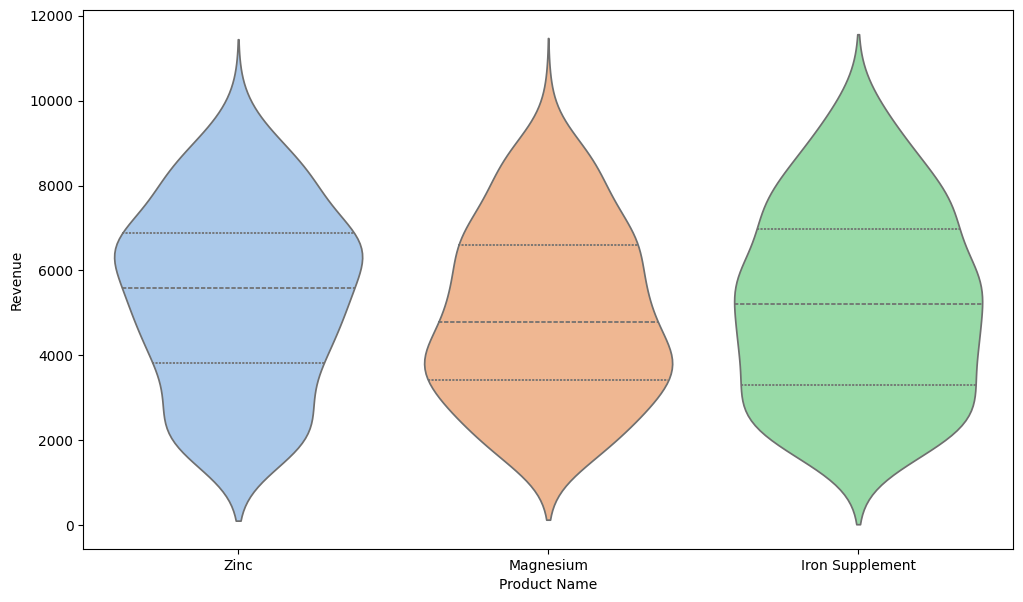

In [ ]:
df_mineral_m = df_supplement[df_supplement['Category']=='Mineral'].copy()

df_mineral_m['month_str'] = df_mineral_m['month_year'].astype(str)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.violinplot(data=df_mineral_m, x='Product Name', y='Revenue', inner='quartile', palette='pastel', hue='Product Name', legend=False)

<Axes: xlabel='Product Name', ylabel='Revenue'>

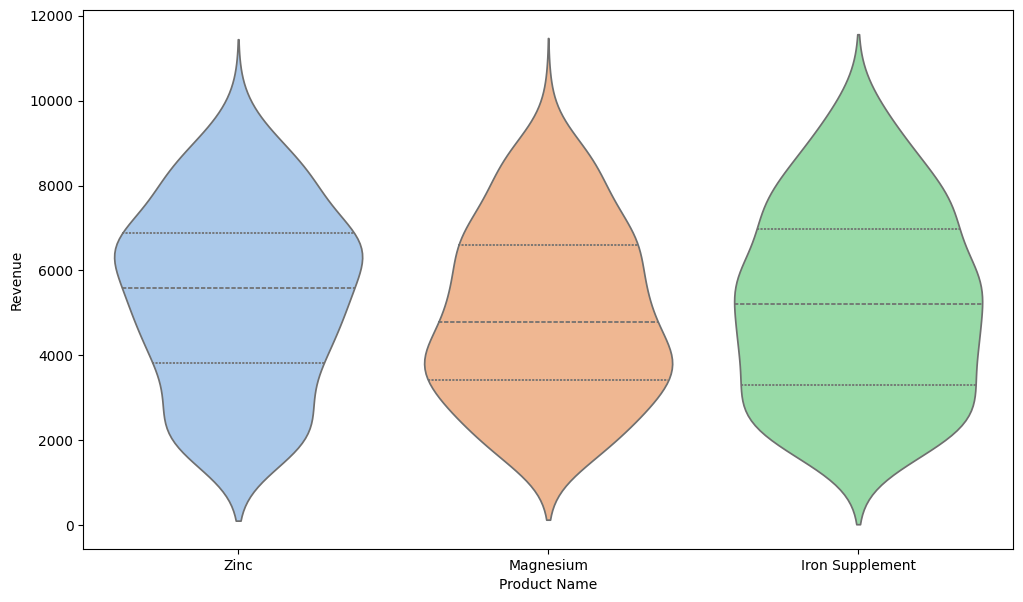

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.violinplot(data=df_mineral, x='Product Name', y='Revenue', inner='quartile', palette='pastel', hue='Product Name', legend=False)

##(5) Based on the violin plot, Zinc recorded the highest median weekly revenue among the mineral products, while Magnesium had the lowest. Although the overall revenue ranges are similar across these products, the distribution shapes differ. According to the quartile line, Zinc consistently achieves higher sales in most weeks, whereas Magnesium's revenue is highly concentrated at a lower level.

---



#Question 6. Calculate the total weekly revenue for each product category. Create a pyramid chart comparing the weekly revenue distributions of Protein and Vitamin. Ensure that the x-axis labels correctly reflect the data values. Add appropriate axis labels and a title to the visualization. Adjust other visual elements as you see fit.

Note. You may create a summary table like the following.

|index|Date|Category|Revenue|
|---|---|---|---|
|0|2020-01-06 |Amino Acid|6343\.26|
|1|2020-01-06 |Fat Burner|4558\.84|
|2|2020-01-06 |Herbal|2803\.69|
|3|2020-01-06 |Hydration|5531\.68|
|4|2020-01-06 |Mineral|16046\.33|


In [ ]:
df_tot = df_supplement.groupby(['Date','Category'])['Revenue'].sum().reset_index().copy()
df_tot.head()

,Date,Category,Revenue
0,2020-01-06,Amino Acid,6343.26
1,2020-01-06,Fat Burner,4558.84
2,2020-01-06,Herbal,2803.69
3,2020-01-06,Hydration,5531.68
4,2020-01-06,Mineral,16046.33


In [ ]:
df_pv = df_tot[df_tot['Category'].isin(['Protein','Vitamin'])].reset_index(drop=True)
df_pv.head()

,Date,Category,Revenue
0,2020-01-06,Protein,6184.26
1,2020-01-06,Vitamin,12736.30
2,2020-01-13,Protein,9369.60
3,2020-01-13,Vitamin,6440.19
4,2020-01-20,Protein,12909.18


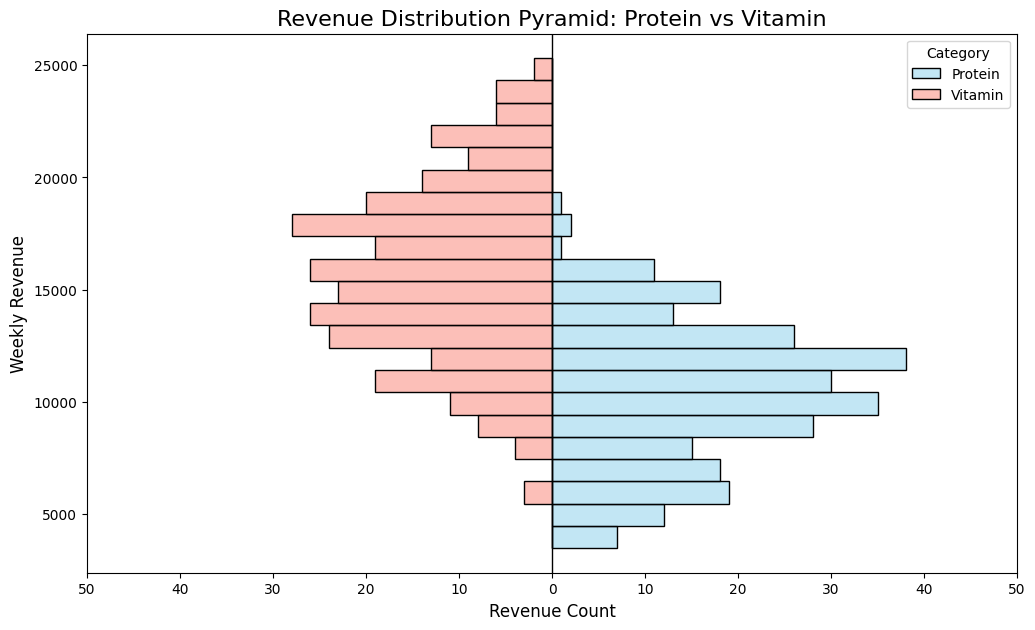

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# df_pv = df_supplement[df_supplement['Category'].isin(['Protein', 'Vitamin'])].copy()

df_pv['weight'] = df_pv['Category'].map({'Protein': 1, 'Vitamin': -1})


plt.figure(figsize=(12, 7))

sns.histplot(
    data=df_pv,
    y='Revenue',
    weights='weight',
    hue='Category',
    binwidth=1000,
    stat='count',
    palette={'Protein': 'skyblue', 'Vitamin': 'salmon'},
)


plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Revenue Count', fontsize=12)
plt.ylabel('Weekly Revenue', fontsize=12)
plt.title('Revenue Distribution Pyramid: Protein vs Vitamin', fontsize=16)

plt.xticks(range(-50, 51, 10))
locs, labels = plt.xticks()
plt.xticks(locs, [str(int(abs(loc))) for loc in locs])

plt.show()

##(6) Vitamin has greater revenue volatility, with a larger portion of its revenue concentrated in the higher ranges compared to Protein.

---



# Question 7. Heatmap

### Create a summary for each month from 2021 to 2024 for the following:
### - Monthly total revenue
### - Monthly total units sold
### - Monthly total units returned
### - Aveage discount offered in month
### - Year of the month

### (7.1) Show the head of the summary table
### (7.2) Generate a heat map using all numeric variables in this summary table
### (7.3) Which variables seem to have high coorelation with each other? Do you think that it makes practical sense?

##(7.1)

In [ ]:
summary_table = df_supplement.groupby('month_year').agg({
    'Revenue': 'sum',
    'Units Sold': 'sum',
    'Units Returned': 'sum',
    'Discount': 'mean',
    'year': 'first'
}).copy()
summary_table.head()

,Revenue,Units Sold,Units Returned,Discount,year
month_year,,,,,
2020-01,290723.89,9547,101,0.120313,2020
2020-02,355213.26,9493,91,0.128125,2020
2020-03,416547.17,12145,123,0.111375,2020
2020-04,326287.92,9605,91,0.138281,2020
2020-05,333210.99,9557,90,0.119375,2020


##

---



##(7.2)

<Axes: >

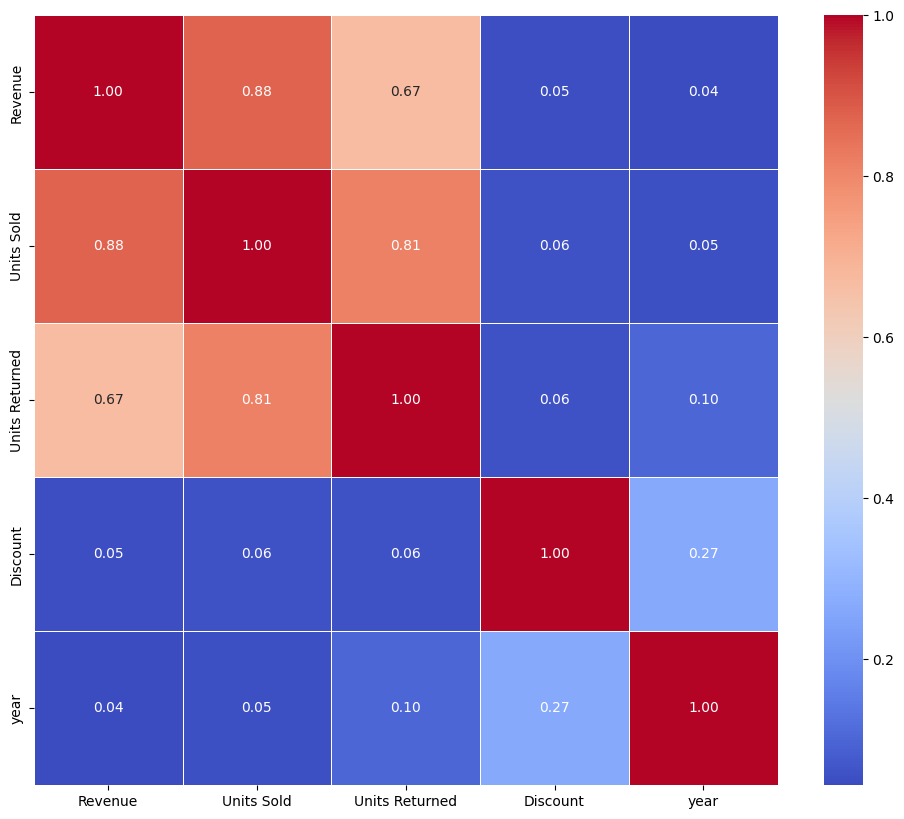

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


correlation_matrix = summary_table.corr()
plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=True)



---



##(7.3)The positive correlation between units sold, revenue, and units returned makes sense because higher sales volume naturally generates more revenue and leads to a higher number of returns. However, the discount rate shows a negative correlation with both sales and revenue, which might seem counterintuitive at the first glance. But, this could indicate that heavy discounts are used as a reactive strategy during slow seasons or applied to underperforming products, failing to boost overall performance. Furthermore, the negative correlation with the year variable suggests a general downward trend in overall business performance over time.

---



# Question 8. Bubble plot

## Create a bubble chart using the 2024 data to visualize monthly revenue, total monthly units sold, total monthly units returned, and location. Assign these variables to visual elements (e.g., x-axis, y-axis, bubble size, color) in a way that makes the chart clear and informative. Briefly explain your key findings from the visualization.

In [ ]:
df_2024 = df_supplement[df_supplement['year'] == 2024].copy()

df_2024_summary = df_2024.groupby(['month_year', 'Location'], as_index=False).agg({
    'Revenue': 'sum',
    'Units Sold': 'sum',
    'Units Returned': 'sum'
}).copy()

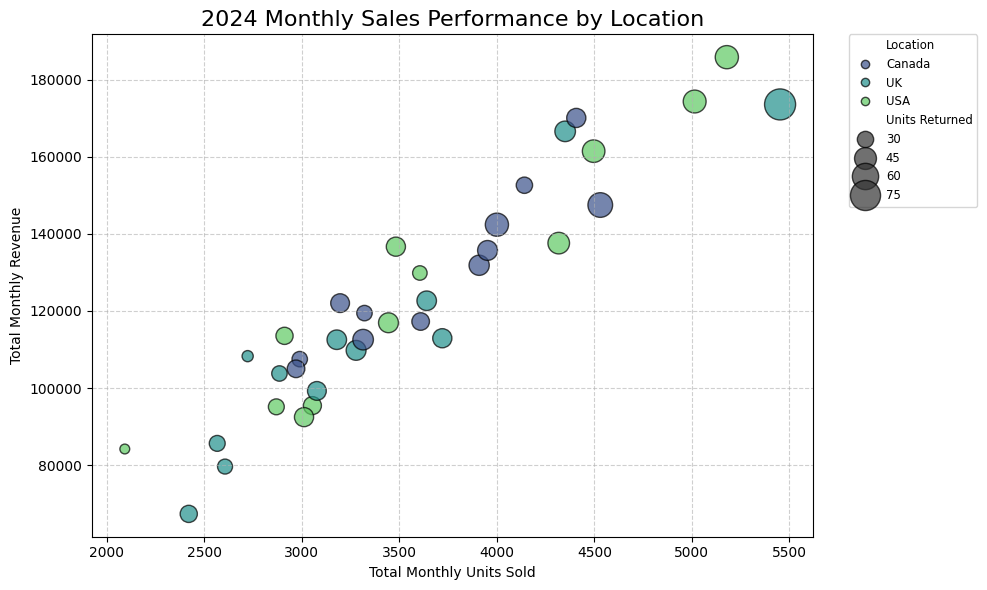

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_2024_summary,
                x='Units Sold',
                y='Revenue',
                hue='Location',
                size='Units Returned',
                sizes=(50, 500),
                alpha=0.7,
                palette='viridis',
                edgecolor='black',
                linewidth=1
                )
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize='small')
plt.title('2024 Monthly Sales Performance by Location', fontsize=16)
plt.xlabel('Total Monthly Units Sold')
plt.ylabel('Total Monthly Revenue')
plt.tight_layout()


##(8)Based on the bubble plot, the US and the UK represent the top-performing markets, with two US months and one UK month positioned in the top-right corner indicating the highest monthly sales and revenue. In contrast, Canada's performance is highly clustered, consistently generating between 100,000 and 170,000 in revenue with 3,000 to 4,600 units sold per month. Additionally, as the number of units sold increases, the bubble size generally becomes larger, showing an expected positive correlation between overall sales volume and the total units returned.

---



# Question 9. There is a claim that the higher the average discount offered, the greater the number of units returned. Create a combined line and bar chart using the 2024 Mineral data to investigate this claim.

### - Filter the dataset to include only records from 2024 and the Mineral category.
### - Create a monthly summary for 2024 for products in the Mineral category, including:
####    -- Total monthly units returned
####   -- Average monthly discount

### Create a combined line and bar chart with the following:
#### - The bar chart should display total monthly units returned.
#### - The line chart should display the average monthly discount offered.

### For visual formatting
#### - Add an appropriate chart title.
#### - Include clear x-axis and y-axis labels.
#### - Adjust the bar color and outline.
#### - Customize the line color and markers.
#### - Adjust other visual elements as needed to improve clarity and presentation.

### Does the visual support the claim for Mineral products in 2024? Briefly explain.

In [ ]:
df_mineral_2024 = df_supplement[(df_supplement['year'] == 2024) & (df_supplement['Category'] == 'Mineral')].copy()

df_2024mineral_summary = df_mineral_2024.groupby('month_year').agg({
    'Units Returned': 'sum',
    'Discount': 'mean'
}).reset_index().copy()

df_2024mineral_summary['month_str'] = df_2024mineral_summary['month_year'].astype(str)
df_2024mineral_summary

,month_year,Units Returned,Discount,month_str
0,2024-01,15,0.113333,2024-01
1,2024-02,14,0.144167,2024-02
2,2024-03,14,0.130000,2024-03
3,2024-04,30,0.174000,2024-04
4,2024-05,21,0.120000,2024-05
5,2024-06,9,0.145833,2024-06
6,2024-07,28,0.114667,2024-07
7,2024-08,13,0.137500,2024-08
8,2024-09,30,0.133333,2024-09
9,2024-10,18,0.115000,2024-10


In [ ]:
df_mineral_2024_p = df_supplement[(df_supplement['year'] == 2024) & (df_supplement['Category'] == 'Protein')].copy()

df_2024mineral_p_summary = df_mineral_2024_p.groupby('month_year').agg({
    'Units Returned': 'sum',
    'Discount': 'mean'
}).reset_index().copy()

df_2024mineral_p_summary['month_str'] = df_2024mineral_p_summary['month_year'].astype(str)
df_2024mineral_p_summary

,month_year,Units Returned,Discount,month_str
0,2024-01,21,0.09900,2024-01
1,2024-02,14,0.08375,2024-02
2,2024-03,17,0.12250,2024-03
3,2024-04,9,0.13000,2024-04
4,2024-05,7,0.08250,2024-05
5,2024-06,17,0.07625,2024-06
6,2024-07,20,0.16600,2024-07
7,2024-08,21,0.17250,2024-08
8,2024-09,15,0.13400,2024-09
9,2024-10,12,0.12000,2024-10


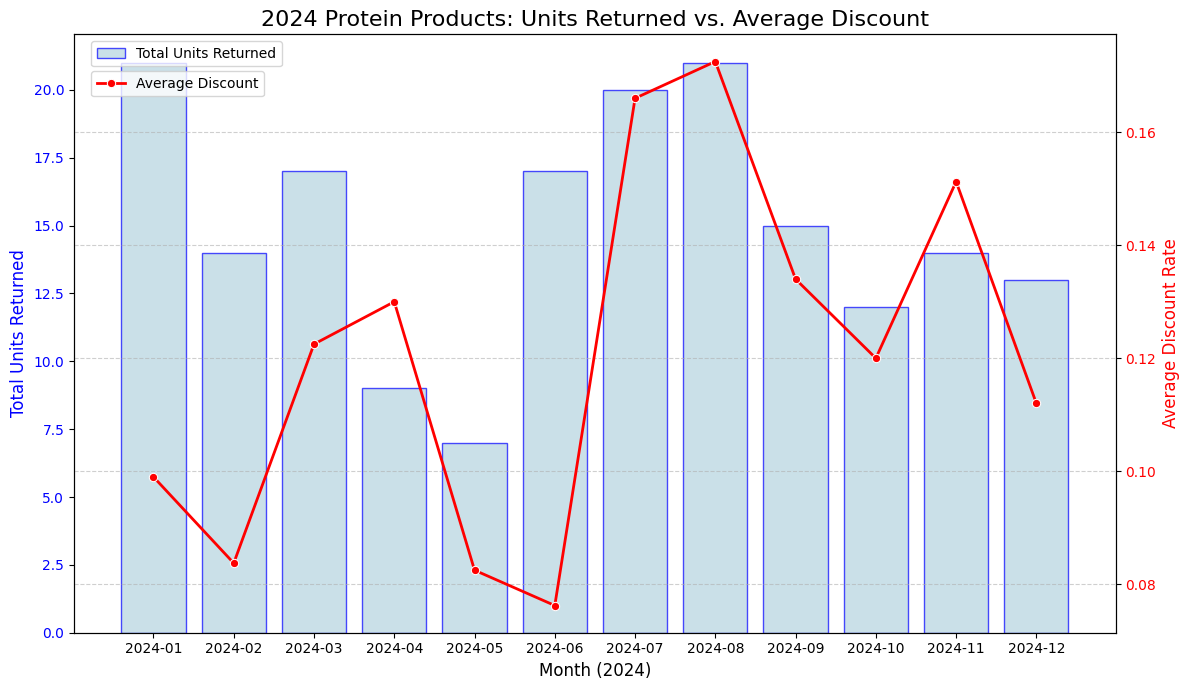

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig, ax1 = plt.subplots(figsize=(12, 7))
sns.barplot(
    x='month_str',
    y='Units Returned',
    data=df_2024mineral_p_summary,
    ax=ax1,
    edgecolor='blue',
    color='lightblue',
    alpha=0.7,
    label='Total Units Returned'
)
ax1.set_xlabel('Month (2024)', fontsize=12)
ax1.set_ylabel('Total Units Returned', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('2024 Protein Products: Units Returned vs. Average Discount', fontsize=16)




ax2 = ax1.twinx()

sns.lineplot(
    x='month_str',
    y='Discount',
    data=df_2024mineral_p_summary,
    ax=ax2,
    color='red',
    marker='o',
    linewidth=2,
    label='Average Discount'
)
ax2.set_ylabel('Average Discount Rate', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')


ax1.legend(loc='upper left', bbox_to_anchor=(0.01, 1))
ax2.legend(loc='upper left', bbox_to_anchor=(0.01, 0.95))

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

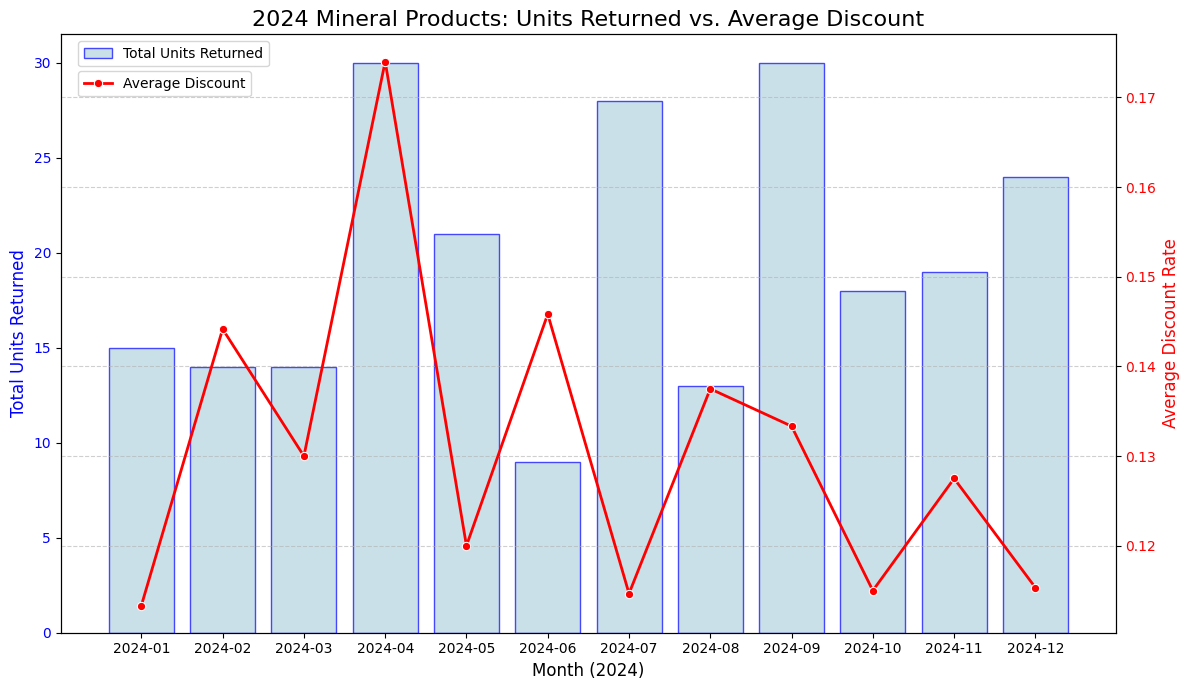

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig, ax1 = plt.subplots(figsize=(12, 7))
sns.barplot(
    x='month_str',
    y='Units Returned',
    data=df_2024mineral_summary,
    ax=ax1,
    edgecolor='blue',
    color='lightblue',
    alpha=0.7,
    label='Total Units Returned'
)
ax1.set_xlabel('Month (2024)', fontsize=12)
ax1.set_ylabel('Total Units Returned', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('2024 Mineral Products: Units Returned vs. Average Discount', fontsize=16)




ax2 = ax1.twinx()

sns.lineplot(
    x='month_str',
    y='Discount',
    data=df_2024mineral_summary,
    ax=ax2,
    color='red',
    marker='o',
    linewidth=2,
    label='Average Discount'
)
ax2.set_ylabel('Average Discount Rate', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')


ax1.legend(loc='upper left', bbox_to_anchor=(0.01, 1))
ax2.legend(loc='upper left', bbox_to_anchor=(0.01, 0.95))

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##(9)From my point of view, the data does not really support the claim that higher average discounts lead to a greater number of units returned. Although both the average discount and the units returned reached their peaks in April 2024, their overall trends do not align closely. For instance, when the average discount dropped sharply from over 0.17 to approximately 0.12 in the following month, the number of returned units did not experience a significant decline. Overall, the average discount rate fluctuates throughout the year without showing a clear or consistent relationship with the volume of returns.

---



# Question 10. In this section, we will create a diverging bar chart to compare the average weekly product revenue between U.S. and non-U.S. locations. Follow the steps below to prepare the data for the visualization:

#### (1) Create a table (using `groupby().agg()` or `pivot_table()`) where each product's revenue appears in its own column. Include an indicator for US vs. non-US locations in the table.

#### (2) Standardize the revenue data for each product, then calculate the standardized mean revenue for U.S. and non-U.S. locations for each product.

#### (3) Use the data generated in Step 2 to construct the diverging bar chart.

# Finally, briefly explain the main findings shown in the visualization.


#### The table from step(1) may look like this.
|index|Date|US|Ashwagandha|BCAA|Biotin|
|---|---|---|---|---|---|
|0|2020-01-06|Non\_US|NaN|6343\.26|4577\.61|
|1|2020-01-06|US|2803\.69|NaN|NaN|
|2|2020-01-13|Non\_US|7228\.55|4656\.0|NaN|
|3|2020-01-13|US|NaN|NaN|3038\.07|
|4|2020-01-20|Non\_US|3664\.44|2528\.8|5153\.61|

#### The table from step(2) may look like this.
|index|Product Name|Non\_US|US|
|---|---|---|---|
|0|Whey Protein|-0\.04|0\.1|
|1|Vitamin C|-0\.03|0\.07|
|2|Fish Oil|-0\.05|0\.11|
|3|Multivitamin|0\.03|-0\.05|
|4|Pre-Workout|-0\.05|0\.11|

In [ ]:
df_supplement['US'] = df_supplement['Location'].map(lambda x:
    'US' if x == 'USA'
    else 'Non_US')

df_step1 = df_supplement.groupby(['Date', 'US', 'Product Name'])['Revenue'].agg('sum').unstack('Product Name').reset_index()
df_step1.columns.name = None

df_step1.head()

,Date,US,Ashwagandha,BCAA,Biotin,Collagen Peptides,Creatine,Electrolyte Powder,Fish Oil,Green Tea Extract,Iron Supplement,Magnesium,Melatonin,Multivitamin,Pre-Workout,Vitamin C,Whey Protein,Zinc
0,2020-01-06,Non_US,NaN,6343.26,4577.61,NaN,4353.66,NaN,2078.51,4558.84,6402.53,2781.84,NaN,2249.80,5568.79,5908.89,4573.14,6861.96
1,2020-01-06,US,2803.69,NaN,NaN,1611.12,NaN,5531.68,NaN,NaN,NaN,NaN,5643.24,NaN,NaN,NaN,NaN,NaN
2,2020-01-13,Non_US,7228.55,4656.00,NaN,7557.60,6498.80,NaN,NaN,NaN,NaN,6016.20,NaN,NaN,1989.51,NaN,1812.00,NaN
3,2020-01-13,US,NaN,NaN,3038.07,NaN,NaN,5348.42,3986.05,3173.76,5752.27,NaN,4657.23,2044.04,NaN,1358.08,NaN,7299.60
4,2020-01-20,Non_US,3664.44,2528.80,5153.61,6345.01,8037.88,NaN,NaN,3112.44,6480.55,4796.82,3418.88,NaN,NaN,3327.17,NaN,NaN


In [ ]:
product_cols = df_step1.columns[2:].tolist()

df_step1[product_cols] = (df_step1[product_cols] - df_step1[product_cols].mean()) / df_step1[product_cols].std()

df_step2 = df_step1.groupby('US')[product_cols].mean().round(2).T.reset_index().rename(columns={'index': 'Product Name'})

df_step2.columns.name = None

df_step2

,Product Name,Non_US,US
0,Ashwagandha,-0.01,0.02
1,BCAA,-0.04,0.10
2,Biotin,0.01,-0.01
3,Collagen Peptides,-0.01,0.01
4,Creatine,0.06,-0.14
5,Electrolyte Powder,0.03,-0.06
6,Fish Oil,-0.05,0.11
7,Green Tea Extract,0.02,-0.05
8,Iron Supplement,-0.04,0.07
9,Magnesium,0.02,-0.04


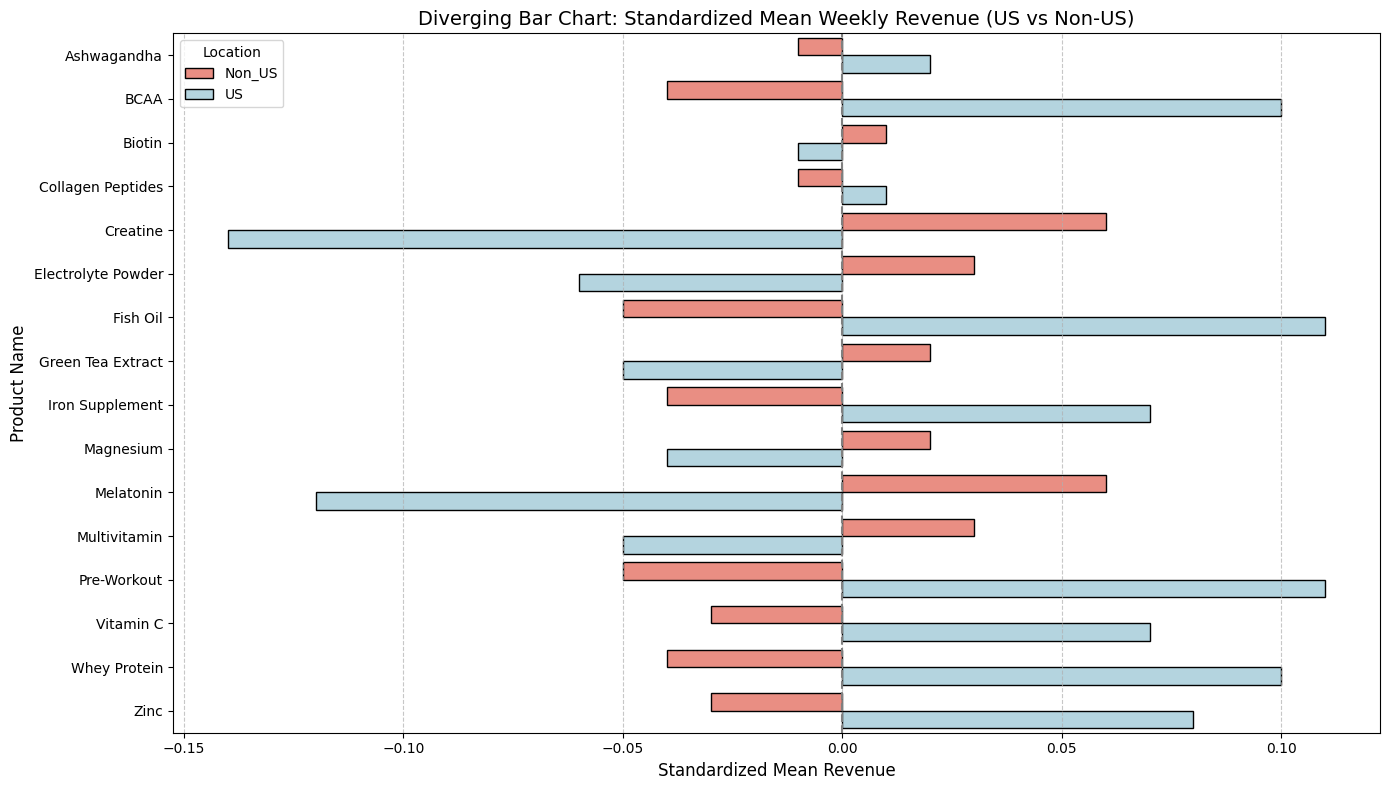

In [ ]:
df_melted = df_step2.melt(
    id_vars=['Product Name'],
    value_vars=['Non_US', 'US'],
    var_name='Location',
    value_name='Standardized Revenue'
)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=df_melted,
    x='Standardized Revenue',
    y='Product Name',
    hue='Location',
    palette={'US': 'lightblue', 'Non_US': 'salmon'},
    errorbar=None,
    dodge=True,
    edgecolor='black'
)

plt.axvline(0, color='gray', linestyle='--', linewidth=1.5)
plt.title('Diverging Bar Chart: Standardized Mean Weekly Revenue (US vs Non-US)', fontsize=14)
plt.xlabel('Standardized Mean Revenue', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##(10)The US market shows a wider spread in standardized mean weekly revenue across products. Some products like Fish Oil, Pre-Workout, and Whey Protein perform noticeably above the global average in the US, while products like Creatine and Melatonin fall well below it. In contrast, the Non-US market tends to stay closer to zero, meaning most products perform more consistently around the global average. It is also worth noticing that for many products, the US and Non-US bars point in opposite directions, suggesting that a product selling well in the US does not mean it sells well in other regions.
---



# Question 11. Time series analysis on monthly sales

### - First, filter the data for the years 2023 to 2025.
### - Calculate the monthly total sales (Units Sold) for each month in the filtered dataset.
### - Develop moving average forecasts using rolling window sizes from 3 to 10.

# Answer the following questions:
### (11.1) Which window size results in the lowest MAD?
### (11.2) Create a line plot showing the actual sales and the moving average forecast developed with the window size you identified in the previous question.
### (11.3) What is the corresponding sales forecast for April 2025?
### (11.4) What is the forecast error in terms of standard deviation?
### (11.5) Assuming the forecast error is normally distributed with a mean of 0, how many units should the company stock to ensure the out-of-stock probability is less than 10%?



In [ ]:
df_2023_2025 = df_supplement[(df_supplement['year']==2023)| (df_supplement['year']==2024) | (df_supplement['year']==2025)].copy()
# df_2023_2025.head()
df_monthly = df_2023_2025.groupby('month_year')['Units Sold'].agg('sum').reset_index()
df_monthly.head()

,month_year,Units Sold
0,2023-01,11955
1,2023-02,9634
2,2023-03,9526
3,2023-04,9678
4,2023-05,12039


In [ ]:
for windowsize in range(3, 11):
    df_monthly[f'MA_{windowsize}'] = (
      df_monthly['Units Sold'].rolling(window=windowsize, min_periods=windowsize).mean().shift(1)
    )

    current_mad = (df_monthly['Units Sold'] - df_monthly[f'MA_{windowsize}']).abs().mean()

    print(f'Window {windowsize}: MAD = {current_mad}')


    # df_monthly[f'MA_{windowsize}'] = df_monthly['Units Sold'].rolling(window=windowsize).mean()

Window 3: MAD = 1221.6805555555554
Window 4: MAD = 1323.1630434782608
Window 5: MAD = 1267.5454545454545
Window 6: MAD = 1190.928571428571
Window 7: MAD = 1255.0571428571427
Window 8: MAD = 1201.4605263157894
Window 9: MAD = 1188.9135802469134
Window 10: MAD = 1222.5117647058821


##(11.1) Window 9 has the lowest MAD

---



##(11.2)

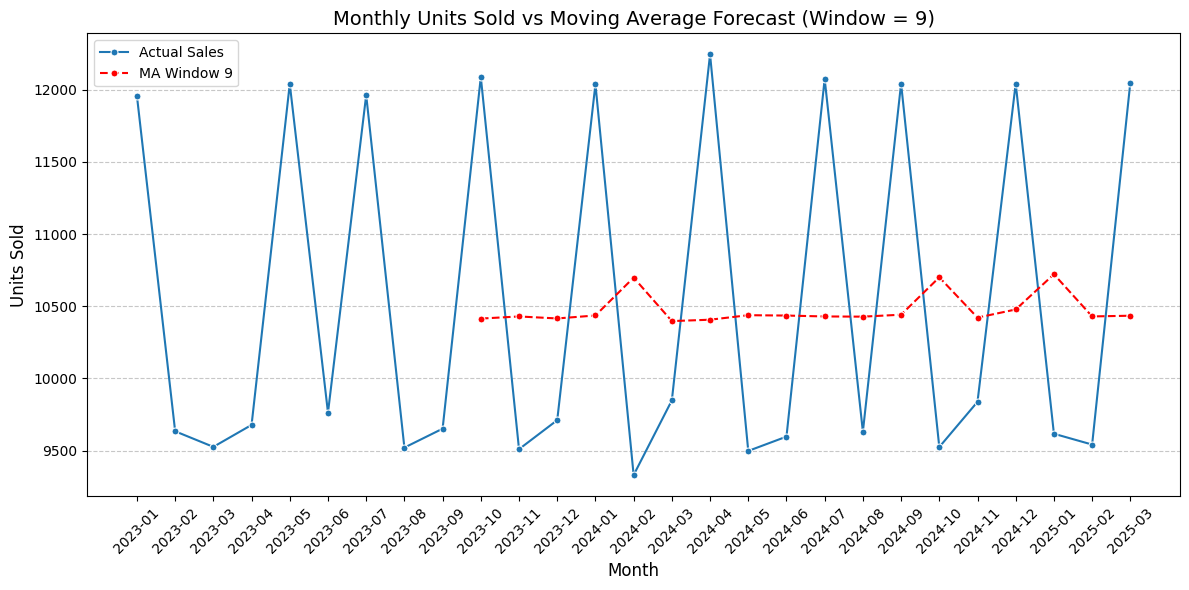

In [ ]:
plt.figure(figsize=(12, 6))

#Ai debug
df_monthly['month_year_str'] = df_monthly['month_year'].astype(str)
#----

sns.lineplot(x='month_year_str', y='Units Sold', data=df_monthly,
             marker='o', markersize=5,
             errorbar=None, label='Actual Sales')

sns.lineplot(x='month_year_str', y='MA_9', data=df_monthly,
             errorbar=None, color='red', linestyle='--',
             marker='o', markersize=5,
             label='MA Window 9')

plt.title('Monthly Units Sold vs Moving Average Forecast (Window = 9)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
mean_absolute_deviation = (df_monthly['Units Sold'] - df_monthly['MA_8']).abs().mean()
mean_absolute_deviation

np.float64(1201.4605263157894)



---

In [ ]:
forecast_apr2025_8 = df_monthly['Units Sold'].iloc[-8:].mean()
print(forecast_apr2025_8)

10535.75


In [ ]:
forecast_apr2025 = df_monthly['Units Sold'].iloc[-4:].mean()
print(forecast_apr2025)

10812.5


##(11.3) 10812.5

---

In [ ]:
forecast_error = df_monthly['Units Sold'] - df_monthly['MA_9']
error_std = forecast_error.std()
error_std

1291.716653221017

In [ ]:
forecast_error_8 = df_monthly['Units Sold'] - df_monthly['MA_8']
error_std_8 = forecast_error_8.std()
error_std_8

1302.0316940286502

##(11.4)1291.716653221017


---

In [ ]:
safe_stock = forecast_apr2025 + 1.28 * error_std
safe_stock

np.float64(12465.897316122902)

In [ ]:
safe_stock_8 = forecast_apr2025_8 + 1.28 * error_std_8
safe_stock_8

np.float64(12202.350568356673)

In [ ]:
1-(12202.350568356673/13000)

0.06135764858794823

##(11.5) 12465.897316122902

---

# Question 12. Autoregression model for monthly sales

## (12.1) Create a PACF plot for the monthly sales data (same data as in the previous question).
## (12.2) Based on the plot, how many lags would you recommend?
## (12.3) Using the selected number of lags, build an AR model and report the statistical summary.
## (12.4) Write the model equation based on the summary output. Explain the meaning of the constant and the coefficient estimates in a business context.
## (12.5) What is the forecast for April 2025? What is the associated forecast error measured as standard deviation?



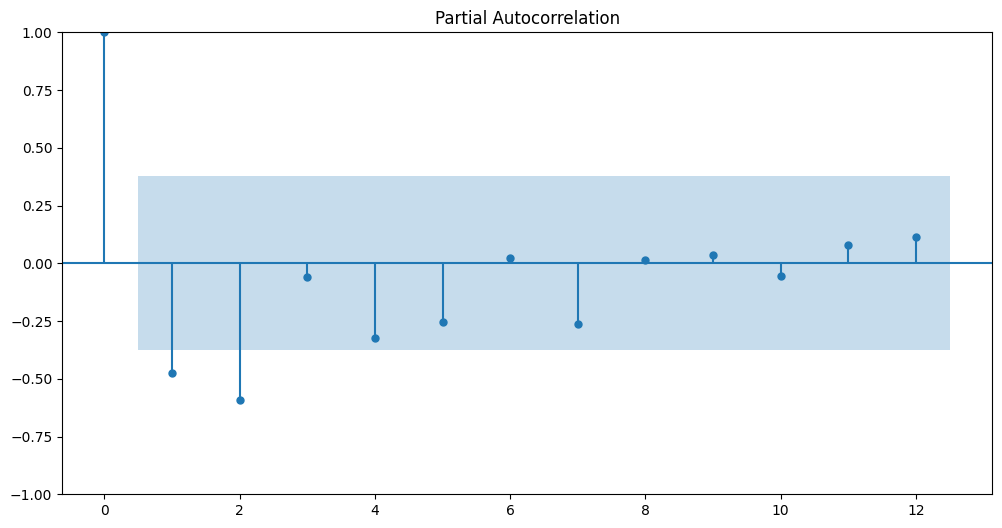

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12, 6))
plot_pacf(df_monthly['Units Sold'], lags=min(len(df_monthly) // 2 - 1, 20), ax=plt.gca())
plt.show()

##(12.1)

---

##(12.2) lags 1 and 2 exceed the confidence band which means that the sales from the previous one month and two months have a statistically significant direct relationship with the current month. Therefore, 2 lags are recommended for the AR model.
---

##(12.3)

In [ ]:
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(df_monthly['Units Sold'], lags=2)
result = model.fit()
print(result.summary())

                            AutoReg Model Results                             
Dep. Variable:             Units Sold   No. Observations:                   27
Model:                     AutoReg(2)   Log Likelihood                -201.929
Method:               Conditional MLE   S.D. of innovations            779.168
Date:                Thu, 05 Mar 2026   AIC                            411.858
Time:                        19:07:48   BIC                            416.734
Sample:                             2   HQIC                           413.211
                                   27                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const          2.608e+04   2781.642      9.374      0.000    2.06e+04    3.15e+04
Units Sold.L1    -0.8376      0.156     -5.383      0.000      -1.143      -0.533
Units Sold.L2    -0.6548      0.152     



---

##(12.4)The model equation is: Unit_Sold(t) = 26080 - 0.8376 × Unit_Sold(t-1) - 0.6548 × Unit_Sold(t-2) + Residual(t)
##The constant of 26,080 means the baseline forecast when no past sales data is taken into account. The coefficient of L1 (-0.8376) indicates that a higher sales volume in the previous month is associated with a lower forecast for the current month. Similarly, the coefficient of L2 (-0.6548) suggests that sales from two months ago also have a negative direct effect on the current month, though the impact is slightly smaller than that of the previous month.

---

In [ ]:
forecast = result.predict(start=len(df_monthly), end=len(df_monthly))
print(forecast)

27    9735.325637
dtype: float64


##(12.5)The AR(2) model forecasts 9,735.33 units for April 2025, with a forecast error standard deviation of 779.17 units.



---